# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1893s 11us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

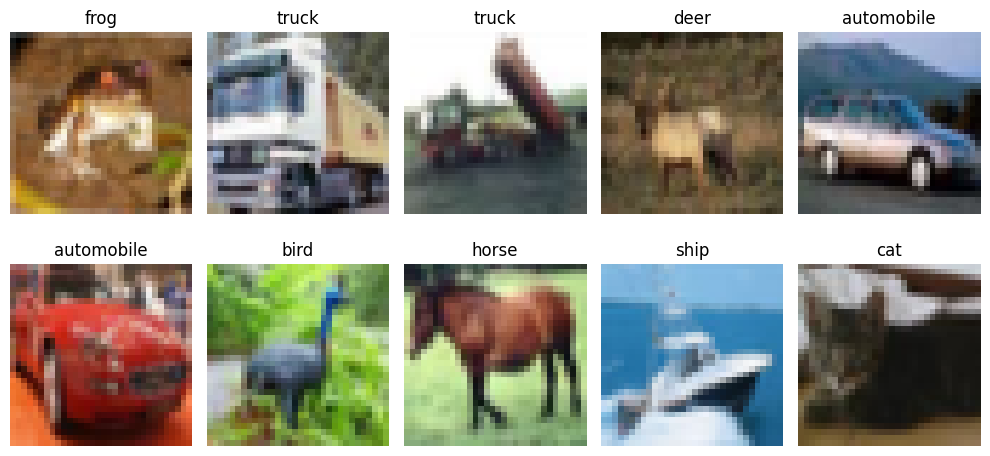

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping( monitor='val_loss', patience=3, restore_best_weights=True )

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [13]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.2667 - loss: 1.9845 - val_accuracy: 0.3290 - val_loss: 1.8552
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3277 - loss: 1.8502 - val_accuracy: 0.3472 - val_loss: 1.7873
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.3459 - loss: 1.7936 - val_accuracy: 0.3688 - val_loss: 1.7531
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.3615 - loss: 1.7583 - val_accuracy: 0.3980 - val_loss: 1.6943
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.3718 - loss: 1.7319 - val_accuracy: 0.4040 - val_loss: 1.6903
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.3802 - loss: 1.7088 - val_accuracy: 0.3978 - val_loss: 1.6740
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.3897 - loss: 1.6794 - val_accuracy: 0.4018 - val_loss: 1.6895
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.3966 - loss: 1.6659 - 

In [14]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4356 - loss: 1.5924
ANN Test Accuracy: 0.43560001254081726


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [15]:
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 364ms/step - accuracy: 0.4316 - loss: 1.5726 - val_accuracy: 0.3430 - val_loss: 1.9228
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 254s 360ms/step - accuracy: 0.5975 - loss: 1.1564 - val_accuracy: 0.4368 - val_loss: 1.8002
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 251s 356ms/step - accuracy: 0.6713 - loss: 0.9542 - val_accuracy: 0.6742 - val_loss: 0.9449
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 255s 347ms/step - accuracy: 0.7193 - loss: 0.8144 - val_accuracy: 0.6648 - val_loss: 0.9866
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 347ms/step - accuracy: 0.7572 - loss: 0.7020 - val_accuracy: 0.7034 - val_loss: 0.8708
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 345ms/step - accuracy: 0.7908 - loss: 0.6046 - val_accuracy: 0.7240 - val_loss: 0.8454
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 259s 341ms/step - accuracy: 0.8179 - loss: 0.5190 - val_accuracy: 0.7216 - val_loss: 0.8629
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 243s 345ms/step - accuracy: 0.8395 -

In [16]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.7117 - loss: 0.8798
CNN Test Accuracy: 0.7117000222206116


## 📈 Compare Learning Curves

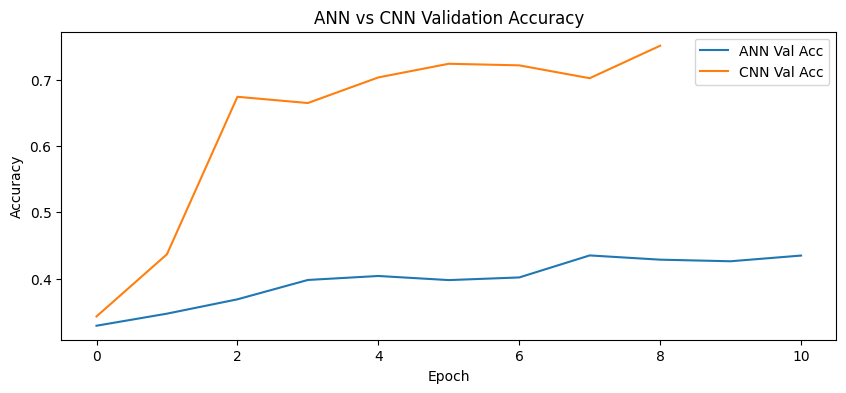

In [17]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([data_augmentation,
 layers.Conv2D( 64,(3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu' ),
   layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(  256,(3,3),  activation='relu'),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10,activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)
aug_history = aug_cnn_model.fit( x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64,
                                callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 345ms/step - accuracy: 0.3877 - loss: 1.6969 - val_accuracy: 0.4536 - val_loss: 1.5072
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 340ms/step - accuracy: 0.4942 - loss: 1.4220 - val_accuracy: 0.5328 - val_loss: 1.2913
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.5463 - loss: 1.2893 - val_accuracy: 0.5696 - val_loss: 1.2920


In [22]:
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm,y_test)

print("Augmented CNN Accuracy:", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.4576 - loss: 1.5151
Augmented CNN Accuracy: 0.4575999975204468


# 📊 Final Comparison Table

In [23]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN","CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc,aug_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4356
1,CNN,0.7117
2,CNN + Augmentation,0.4576


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**